# SC-CE light — demo
### Selective classification via counterfactual explanations

This notebook runs the whole SC-CE pipeline end to end on a synthetic dataset:

1. **Data** — `make_classification`, split into *train / calibration / test*.
2. **Black box** — an MLP trained on the train split.
3. **Counterfactuals** — Growing Spheres generates `NUM_CF` counterfactuals per calibration and test instance.
4. **Distances** — Euclidean distance between each instance and its counterfactuals, aggregated per instance (`min`, `mean`, `max`).
5. **Rejectors** — thresholds calibrated on the calibration split for a grid of target coverages:
   - `PlugInRule`: rejects low-confidence predictions (baseline);
   - `CFDistRejector`: rejects instances whose counterfactuals are *close*, i.e. that sit near the decision boundary.
6. **Evaluation** — non-rejected accuracy, classification quality and rejection quality on the test split.
7. **Explaining a rejection** — the closest counterfactual shows *why* the model abstains.

> Bonsignori, Punzi, Pellungrini, Giannotti — *"I know that I don't know... and I explain why": Robust abstention via counterfactual explanations*, IEEE Access, 2026. doi:10.1109/ACCESS.2026.3705102

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

from scce_light import (GrowingSpheres, PlugInRule, CFDistRejector,
                        generate_counterfactuals, cf_distances, euclidean, evaluate)

SEED = 42
NUM_CF = 32            # counterfactuals per instance (as in the SC-CE config)
GS_PARAMS = dict(n_in_layer=200, first_radius=0.05, decrease_radius=2.0, sparse=True)

# plotting style: recessive grid/axes, fixed categorical colours, neutral baseline
COLORS = {'CF min': '#2a78d6', 'CF mean': '#eb6834', 'CF max': '#1baf7a',
          'CF min (gamma)': "#558fd6", 'CF mean (gamma)': "#e98b66", 'CF max (gamma)': "#41b18a",
            'PlugInRule': '#52514e'}
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#b8b7b1', 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e',
    'ytick.color': '#52514e', 'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.8,
    'lines.linewidth': 2, 'legend.frameon': False,
})

## 1. Data
A binary problem with 6 features (4 informative) and 5% label noise, so that some errors are unavoidable and a reject option is useful.
Splits: 60% train, 20% calibration, 20% test. Features are standardised (fit on train only): Growing Spheres explores the space
with isotropic spheres, so all features should live on the same scale.

In [2]:
X, y = make_classification(n_samples=3000, n_features=6, n_informative=4, n_redundant=0,
                           n_clusters_per_class=2, class_sep=1.0, flip_y=0.05, random_state=SEED)
feature_names = [f'x{i}' for i in range(X.shape[1])]

X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=SEED)
X_cal, X_test, y_cal, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train, X_cal, X_test = (scaler.transform(a) for a in (X_train, X_cal, X_test))
print(f'train {X_train.shape}, calibration {X_cal.shape}, test {X_test.shape}')

train (1800, 6), calibration (600, 6), test (600, 6)


## 2. Black-box classifier

In [3]:
model = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=1000, random_state=SEED).fit(X_train, y_train)
for name, (Xs, ys) in {'train': (X_train, y_train), 'calibration': (X_cal, y_cal), 'test': (X_test, y_test)}.items():
    print(f'{name:>12} accuracy: {accuracy_score(ys, model.predict(Xs)):.3f}')

       train accuracy: 0.971
 calibration accuracy: 0.920
        test accuracy: 0.905


## 3. Counterfactuals with Growing Spheres
For each instance *x*, Growing Spheres samples points in spherical layers of growing radius around *x* until some of them
are predicted with a different class (*enemies*). The `NUM_CF` enemies closest to *x* are kept and sparsified (features are
reset to their original value as long as the prediction stays flipped).

Generation is the expensive step, so it runs once per split and is reused by every rejector.

In [4]:
gs = GrowingSpheres(model.predict, random_state=SEED, **GS_PARAMS)

cfs_cal = generate_counterfactuals(gs, X_cal, num_cf=NUM_CF)
cfs_test = generate_counterfactuals(gs, X_test, num_cf=NUM_CF)

# sanity check: every counterfactual must flip the prediction
validity = np.mean([np.all(model.predict(c) != p) for c, p in zip(cfs_test, model.predict(X_test))])
print(f'instances whose counterfactuals are all valid: {validity:.1%}')

Generated 32 counterfactuals for 600 instances in 71.4s


Generated 32 counterfactuals for 600 instances in 69.8s
instances whose counterfactuals are all valid: 100.0%


In [5]:
i = 0
x = X_test[i]
print(f'instance {i}: predicted {model.predict(x[None])[0]}, true {y_test[i]}')
pd.DataFrame(np.vstack([x, cfs_test[i][:5]]), columns=feature_names,
             index=['x'] + [f'cf {k}' for k in range(5)]).round(3)

instance 0: predicted 1, true 1


,x0,x1,x2,x3,x4,x5
x,-1.15,0.408,-0.491,-1.715,0.530,-0.576
cf 0,-1.15,0.604,-0.155,-1.715,0.792,-0.771
cf 1,-1.15,0.408,0.100,-1.715,0.530,-0.576
cf 2,-1.15,0.668,-0.249,-1.715,0.861,-0.745
cf 3,-1.15,0.408,-0.284,-1.715,0.975,-0.730
cf 4,-1.15,0.408,-0.322,-1.715,0.968,-0.780


## 4. Counterfactual distances
The Euclidean distance between *x* and each of its counterfactuals is aggregated into one score per instance.
The intuition behind SC-CE: **if a small change flips the prediction, the model should not be trusted on that instance.**

In [6]:
AGGS = ['min', 'mean', 'max']
dist_cal = {a: cf_distances(X_cal, cfs_cal, distance=euclidean, how=a) for a in AGGS}
dist_test = {a: cf_distances(X_test, cfs_test, distance=euclidean, how=a) for a in AGGS}

correct_test = model.predict(X_test) == y_test
pd.DataFrame({f'{a} distance': [dist_test[a][correct_test].mean(), dist_test[a][~correct_test].mean()] for a in AGGS},
             index=['correct predictions', 'wrong predictions']).round(3)

,min distance,mean distance,max distance
correct predictions,0.352,0.383,0.426
wrong predictions,0.159,0.176,0.199


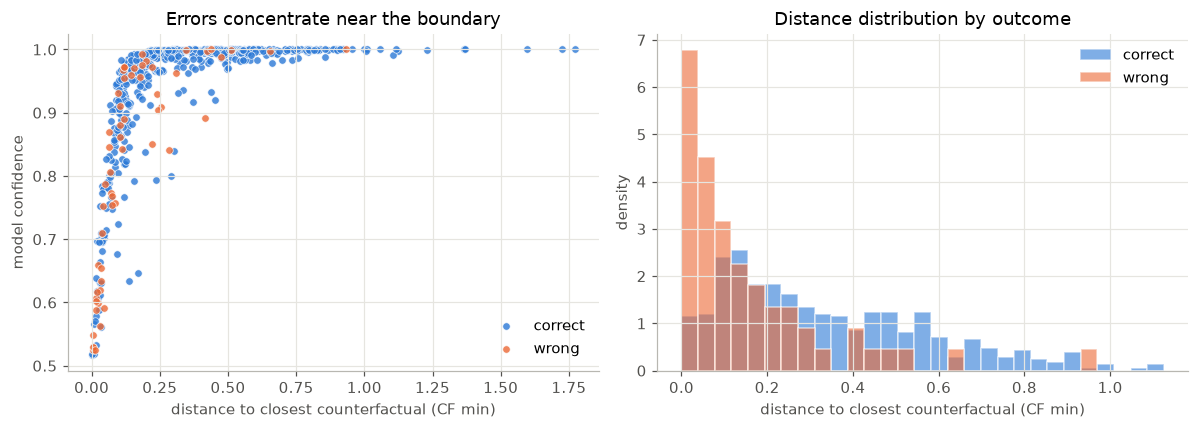

In [7]:
conf_test = model.predict_proba(X_test).max(axis=1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.scatter(dist_test['min'][correct_test], conf_test[correct_test], s=24, c='#2a78d6',
           edgecolor='white', linewidth=0.5, label='correct',alpha=0.8)
ax.scatter(dist_test['min'][~correct_test], conf_test[~correct_test], s=24, c='#eb6834',
           edgecolor='white', linewidth=0.5, label='wrong',alpha=0.8)
ax.set(xlabel='distance to closest counterfactual (CF min)', ylabel='model confidence',
       title='Errors concentrate near the boundary')
ax.legend()

ax = axes[1]
bins = np.linspace(0, np.quantile(dist_test['min'], 0.99), 30)
ax.hist(dist_test['min'][correct_test], bins=bins, density=True, color='#2a78d6', alpha=0.6,
        edgecolor='white', label='correct')
ax.hist(dist_test['min'][~correct_test], bins=bins, density=True, color='#eb6834', alpha=0.6,
        edgecolor='white', label='wrong')
ax.set(xlabel='distance to closest counterfactual (CF min)', ylabel='density',
       title='Distance distribution by outcome')
ax.legend()
plt.tight_layout()

## 5. Calibrating the rejectors
For every target coverage *c*, the threshold is the (1 − *c*)-quantile of the calibration scores
(confidence for `PlugInRule`, counterfactual distance for `CFDistRejector`). A test instance is accepted iff its
score is at least the threshold. With `use_gamma=True` the quantiles come from a Gamma distribution fitted on the
calibration distances instead of the empirical ones.

In [8]:
coverages = np.round(np.arange(1.0, 0.49, -0.05), 2)

plugin = PlugInRule(model).calibrate(X_cal, coverages)
cf_rejectors = {f'CF {a}': CFDistRejector(model).calibrate(dist_cal[a], coverages) for a in AGGS}
cf_rejectors_gamma = {f'CF {a} (gamma)': CFDistRejector(model, use_gamma=True).calibrate(dist_cal[a], coverages)
                      for a in AGGS}

## 6. Evaluation on the test split
Metrics (Condessa et al., 2017), computed on the accepted/rejected test instances:
- **non-rejected accuracy**: accuracy on the accepted instances;
- **classification quality**: fraction of correct decisions (correct & accepted, or wrong & rejected);
- **rejection quality**: how much more concentrated the errors are among the rejected instances than overall (1 = random rejection).

This is a demo, not a benchmark: on this synthetic problem the two rejection criteria perform similarly, and
`min` / `mean` / `max` almost coincide because the sparsified counterfactuals of an instance end up close to each other.
See the paper for the comparison on real datasets and several black boxes.

In [9]:
y_pred_test = model.predict(X_test)
results = pd.concat(
    [evaluate(plugin, y_test, y_pred_test, X_test, coverages, name='PlugInRule')]
    + [evaluate(r, y_test, y_pred_test, dist_test[n.split()[1]], coverages, name=n)
       for n, r in {**cf_rejectors, **cf_rejectors_gamma}.items()],
    ignore_index=True)

(results[results.target_coverage.isin([0.9, 0.8, 0.7])]
 .pivot(index='rejector', columns='target_coverage', values=['coverage', 'nonrejected_accuracy', 'rejection_quality'])
 .round(3))

coverage               nonrejected_accuracy                \
target_coverage      0.7    0.8    0.9                  0.7    0.8    0.9   
rejector                                                                    
CF max             0.682  0.802  0.910                0.954  0.944  0.930   
CF max (gamma)     0.700  0.830  0.915                0.952  0.940  0.931   
CF mean            0.683  0.802  0.910                0.954  0.944  0.930   
CF mean (gamma)    0.700  0.828  0.915                0.952  0.940  0.931   
CF min             0.683  0.805  0.910                0.954  0.944  0.930   
CF min (gamma)     0.697  0.830  0.912                0.952  0.940  0.931   
PlugInRule         0.727  0.810  0.920                0.956  0.947  0.928   

                rejection_quality                
target_coverage               0.7    0.8    0.9  
rejector                                         
CF max                      2.366  3.211  5.171  
CF max (gamma)              2.465  3.429  5.656  
CF mean                     2.382  3.211  5.171  
CF mean (gamma)             2.465  3.384  5.656  
CF min                      2.382  3.285  5.171  
CF min (gamma)              2.431  3.429  5.324  
PlugInRule                  2.873  3.558  5.224

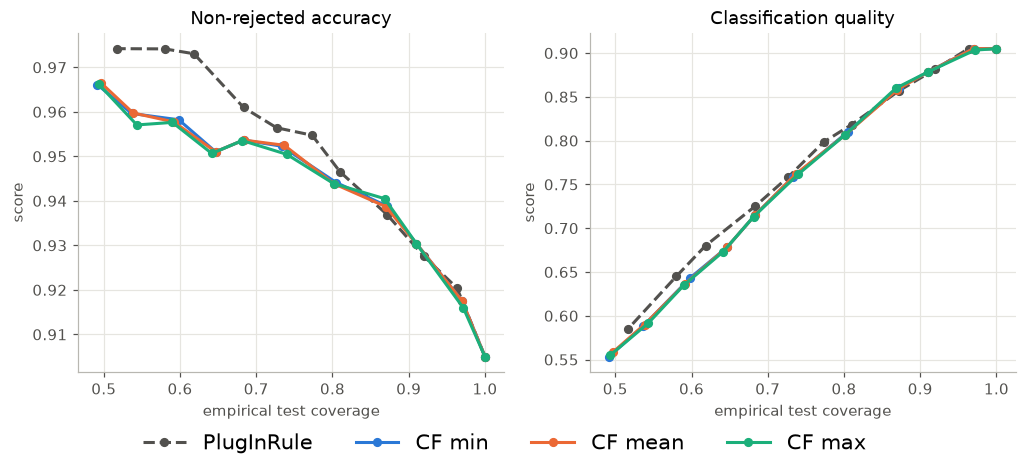

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
metrics = [('nonrejected_accuracy', 'Non-rejected accuracy'), ('classification_quality', 'Classification quality')]
for ax, (metric, title) in zip(axes, metrics):
    for name in ['PlugInRule', 
                 'CF min', 'CF mean', 'CF max']:
        r = results[results.rejector == name]
        ax.plot(r.coverage, r[metric], marker='o', markersize=5, color=COLORS[name],
                linestyle='--' if name == 'PlugInRule' or "gamma" in name else '-', label=name)
    ax.set(xlabel='empirical test coverage', title=title)
axes[0].set_ylabel('score')
axes[1].set_ylabel('score')
axes[0].legend(ncol=4, bbox_to_anchor=(1, -0.3), loc='lower center',fontsize=14)

## 7. Explaining a rejection
A `CFDistRejector` decision comes with its own explanation: the closest counterfactual is a concrete, minimal change that
flips the prediction. The two rejectors do not reject the same instances: below, at 80% coverage, we pick the instance rejected
by `CFDistRejector` on which the model is *most confident* — a confident but fragile prediction.

In [11]:
COV = 0.8
rej = cf_rejectors['CF min']
accepted = rej.accept(dist_test['min'], COV)
threshold = rej.thresholds_[np.flatnonzero(np.isclose(coverages, COV))[0]]

accepted_plg = plugin.accept(X_test, COV)
print(f'Rejected by both: {np.sum(~accepted & ~accepted_plg)}, only by CF min: {np.sum(~accepted & accepted_plg)}, '
      f'only by PlugInRule: {np.sum(accepted & ~accepted_plg)}')
print()

j = np.flatnonzero(~accepted)[np.argmax(conf_test[~accepted])]
x = X_test[j]
closest = cfs_test[j][np.argmin(euclidean(cfs_test[j], x))]
p_x, p_cf = model.predict_proba(x[None])[0], model.predict_proba(closest[None])[0]

print(f'Test instance {j}: predicted class {p_x.argmax()} (p={p_x.max():.2f}), true class {y_test[j]}')
print(f'Distance to closest counterfactual: {dist_test["min"][j]:.3f} < threshold {threshold:.3f} -> REJECTED'
      f' (PlugInRule {"accepts" if accepted_plg[j] else "rejects"} it)')
print(f'The counterfactual is predicted as class {p_cf.argmax()} (p={p_cf.max():.2f}) after changing:')
change = pd.DataFrame({'x': x, 'counterfactual': closest, 'change': closest - x}, index=feature_names)
change[change.change.abs() > 1e-9].round(3)

Rejected by both: 91, only by CF min: 26, only by PlugInRule: 23

Test instance 474: predicted class 0 (p=0.97), true class 0
Distance to closest counterfactual: 0.107 < threshold 0.108 -> REJECTED (PlugInRule accepts it)
The counterfactual is predicted as class 1 (p=0.54) after changing:


,x,counterfactual,change
x0,-0.584,-0.633,-0.048
x2,-0.200,-0.275,-0.074
x4,-0.831,-0.777,0.054
x5,-1.026,-1.050,-0.024


## Where to go next
- Swap `MLPClassifier` for any scikit-learn classifier exposing `predict` / `predict_proba`.
- Swap `make_classification` for your own data (standardise continuous features first).
- `GrowingSpheres` is only one generator: any object with a `generate(x, num_cf)` method returning an array of counterfactuals plugs into `generate_counterfactuals`.